# G3WM6 — Intraday Volume Monotonicity Check
คำถาม: ทุกๆ snapshot ใหม่ ค่า call_value / put_value ต่อ strike ใน intraday tab มีแต่ >= เสมอไหม หรือบางครั้งลดลงด้วย?

`call_value` / `put_value` = intraday cumulative volume ณ เวลานั้น

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SNAP_DIR = Path('../data/snapshots/vol2vol/gold/G3WM6')
files = sorted(SNAP_DIR.glob('*.json'))
print(f'{len(files)} snapshots found')
for f in files:
    print(' ', f.name)

25 snapshots found
  2026-06-17T002520.json
  2026-06-17T003701.json
  2026-06-17T004853.json
  2026-06-17T005051.json
  2026-06-17T015238.json
  2026-06-17T025418.json
  2026-06-17T035600.json
  2026-06-17T045746.json
  2026-06-17T055927.json
  2026-06-17T070102.json
  2026-06-17T080245.json
  2026-06-17T090426.json
  2026-06-17T100613.json
  2026-06-17T110756.json
  2026-06-17T120943.json
  2026-06-17T133147.json
  2026-06-17T143330.json
  2026-06-17T153523.json
  2026-06-17T163737.json
  2026-06-17T173915.json
  2026-06-17T184101.json
  2026-06-17T194648.json
  2026-06-17T204834.json
  2026-06-17T215025.json
  2026-06-17T225223.json


In [2]:
# โหลด intraday tab จากทุก snapshot → list ของ dict {fetched_at, strike: {call, put}}
snaps = []
for f in files:
    d = json.loads(f.read_text())
    intra = d['tabs']['intraday']
    row = {'fetched_at': intra['fetched_at'], 'future_price': intra['future_price']}
    for s in intra['strikes']:
        row[f"call_{s['strike']}"] = s['call_value']
        row[f"put_{s['strike']}"] = s['put_value']
    snaps.append(row)

df = pd.DataFrame(snaps)
df['fetched_at'] = pd.to_datetime(df['fetched_at'])
df = df.sort_values('fetched_at').reset_index(drop=True)

# แยก cols
call_cols = sorted([c for c in df.columns if c.startswith('call_')], key=lambda c: float(c.split('_')[1]))
put_cols  = sorted([c for c in df.columns if c.startswith('put_')],  key=lambda c: float(c.split('_')[1]))

print(f'Strikes: {len(call_cols)}')
print(f'Time range: {df.fetched_at.iloc[0]} → {df.fetched_at.iloc[-1]}')
df[['fetched_at', 'future_price']].head(5)

Strikes: 62
Time range: 2026-06-17 00:25:17.337155 → 2026-06-17 22:52:20.303856


,fetched_at,future_price
0,2026-06-17 00:25:17.337155,4357.8
1,2026-06-17 00:36:58.480967,4349.3
2,2026-06-17 00:48:50.452241,4358.8
3,2026-06-17 00:50:47.819706,4357.9
4,2026-06-17 01:52:36.095049,4359.9


In [3]:
# ── ตรวจ monotonicity ──────────────────────────────────────────────────────────
# สำหรับแต่ละ consecutive pair (t, t+1), หา strike ที่ value ลดลง

decreases = []

for i in range(1, len(df)):
    prev, curr = df.iloc[i-1], df.iloc[i]
    t_prev = prev.fetched_at.strftime('%H:%M')
    t_curr = curr.fetched_at.strftime('%H:%M')

    for col in call_cols + put_cols:
        side  = 'call' if col.startswith('call') else 'put'
        strike = float(col.split('_')[1])
        v_prev = prev[col] if col in prev.index else 0
        v_curr = curr[col] if col in curr.index else 0

        if pd.isna(v_prev): v_prev = 0
        if pd.isna(v_curr): v_curr = 0

        if v_curr < v_prev:
            decreases.append({
                'from': t_prev, 'to': t_curr,
                'side': side, 'strike': strike,
                'prev': v_prev, 'curr': v_curr,
                'delta': v_curr - v_prev,
            })

dec_df = pd.DataFrame(decreases)
print(f'Total decreases found: {len(dec_df)}')
if len(dec_df):
    print(dec_df.sort_values('delta').head(20).to_string(index=False))

Total decreases found: 123
 from    to side  strike  prev  curr  delta
05:59 07:01  put  4300.0 369.0   0.0 -369.0
03:55 04:57  put  4350.0 309.0   0.0 -309.0
08:02 09:04  put  4250.0 169.0   1.0 -168.0
20:48 21:50  put  4290.0 163.0   0.0 -163.0
03:55 04:57  put  4320.0 158.0   0.0 -158.0
05:59 07:01 call  4400.0 161.0  30.0 -131.0
05:59 07:01 call  4390.0 120.0   0.0 -120.0
03:55 04:57  put  4285.0 106.0   0.0 -106.0
21:50 22:52  put  4330.0  77.0   0.0  -77.0
02:54 03:55 call  4500.0  74.0   0.0  -74.0
03:55 04:57  put  4335.0  60.0   0.0  -60.0
03:55 04:57 call  4425.0  58.0   0.0  -58.0
05:59 07:01  put  4325.0  51.0   0.0  -51.0
05:59 07:01  put  4345.0  50.0   0.0  -50.0
05:59 07:01 call  4450.0  46.0   0.0  -46.0
21:50 22:52  put  4325.0  44.0   0.0  -44.0
08:02 09:04  put  4235.0  44.0   3.0  -41.0
05:59 07:01  put  4340.0  71.0  30.0  -41.0
21:50 22:52  put  4320.0  40.0   0.0  -40.0
05:59 07:01  put  4225.0  39.0   0.0  -39.0


In [4]:
# ── สรุปสถิติ ─────────────────────────────────────────────────────────────────
total_obs = (len(df) - 1) * (len(call_cols) + len(put_cols))
n_inc = sum(1 for col in call_cols + put_cols
            for i in range(1, len(df))
            if (df[col].fillna(0).iloc[i] > df[col].fillna(0).iloc[i-1]))
n_flat = sum(1 for col in call_cols + put_cols
             for i in range(1, len(df))
             if (df[col].fillna(0).iloc[i] == df[col].fillna(0).iloc[i-1]))
n_dec  = len(dec_df)

print(f'Total (strike × transition) observations : {total_obs:,}')
print(f'  Increased  (>)  : {n_inc:>7,}  ({n_inc/total_obs*100:.1f}%)')
print(f'  Unchanged  (==) : {n_flat:>7,}  ({n_flat/total_obs*100:.1f}%)')
print(f'  Decreased  (<)  : {n_dec:>7,}  ({n_dec/total_obs*100:.1f}%)')
print()
if n_dec == 0:
    print('✅  Monotonically non-decreasing — ไม่พบการลดลงเลย')
else:
    print(f'⚠️  พบการลดลง {n_dec} ครั้ง — ไม่ใช่ monotonic 100%')

Total (strike × transition) observations : 2,976
  Increased  (>)  :     396  (13.3%)
  Unchanged  (==) :   2,457  (82.6%)
  Decreased  (<)  :     123  (4.1%)

⚠️  พบการลดลง 123 ครั้ง — ไม่ใช่ monotonic 100%


/var/folders/mk/2td63cj508dcrlv6ym3pjjnh0000gn/T/ipykernel_7284/694354612.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


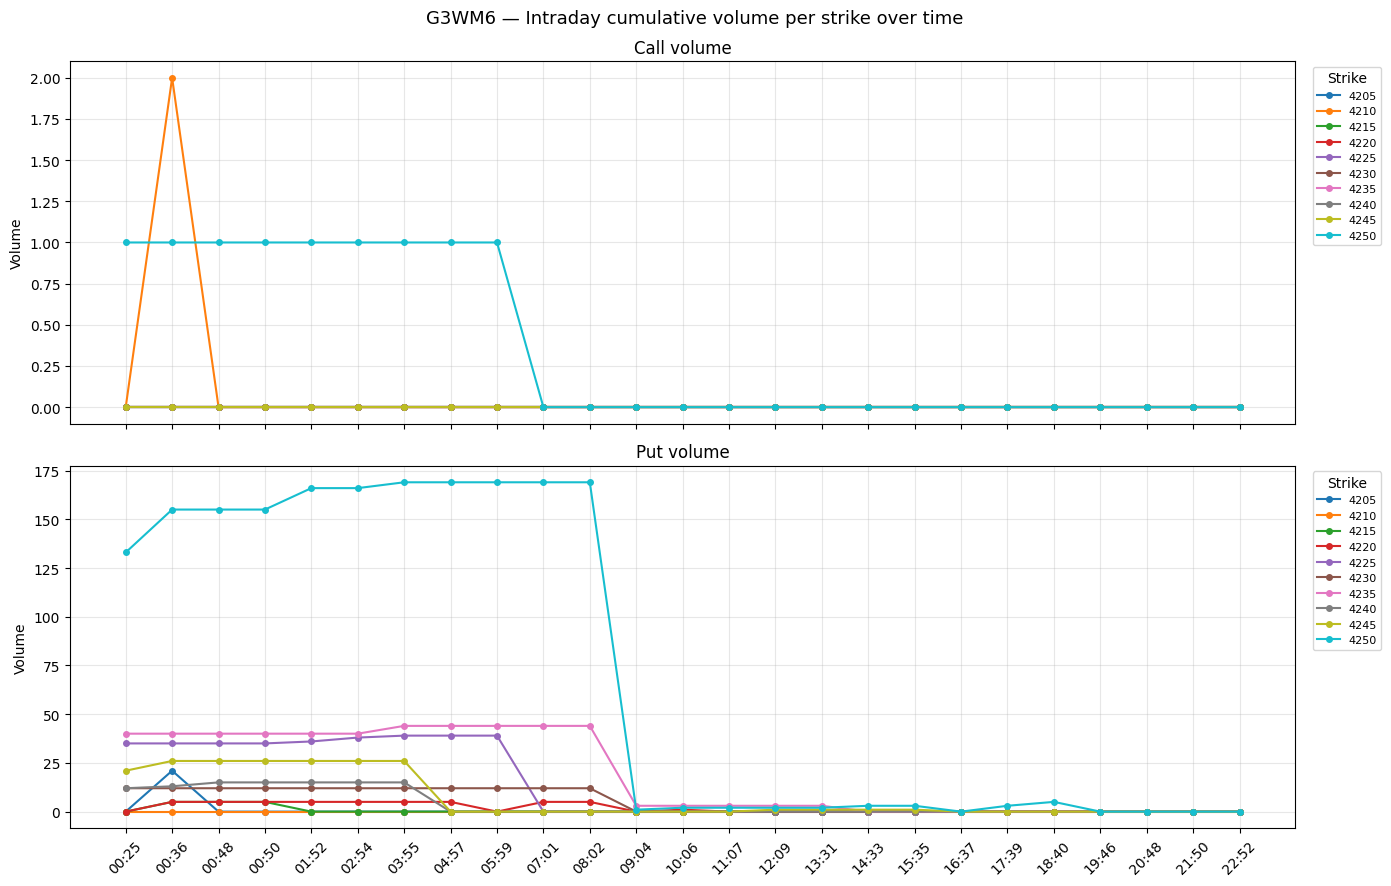

In [5]:
# ── กราฟ: intraday volume สะสม ต่อ strike (top-10 strikes by final volume) ────

times = df.fetched_at.dt.strftime('%H:%M').tolist()

# top 10 strikes by max call+put volume
final = df.iloc[-1]
total_by_strike = {
    float(c.split('_')[1]): final.get(c, 0) + final.get(c.replace('call','put'), 0)
    for c in call_cols
}
top10 = sorted(total_by_strike, key=total_by_strike.get, reverse=True)[:10]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('G3WM6 — Intraday cumulative volume per strike over time', fontsize=13)

cmap = plt.cm.get_cmap('tab10')
for j, strike in enumerate(sorted(top10)):
    c_col = f'call_{strike}'
    p_col = f'put_{strike}'
    c_vals = df[c_col].fillna(0).tolist() if c_col in df.columns else [0]*len(df)
    p_vals = df[p_col].fillna(0).tolist() if p_col in df.columns else [0]*len(df)
    color  = cmap(j / len(top10))
    axes[0].plot(times, c_vals, marker='o', ms=4, color=color, label=f'{int(strike)}')
    axes[1].plot(times, p_vals, marker='o', ms=4, color=color, label=f'{int(strike)}')

axes[0].set_title('Call volume')
axes[1].set_title('Put volume')
for ax in axes:
    ax.set_ylabel('Volume')
    ax.legend(title='Strike', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

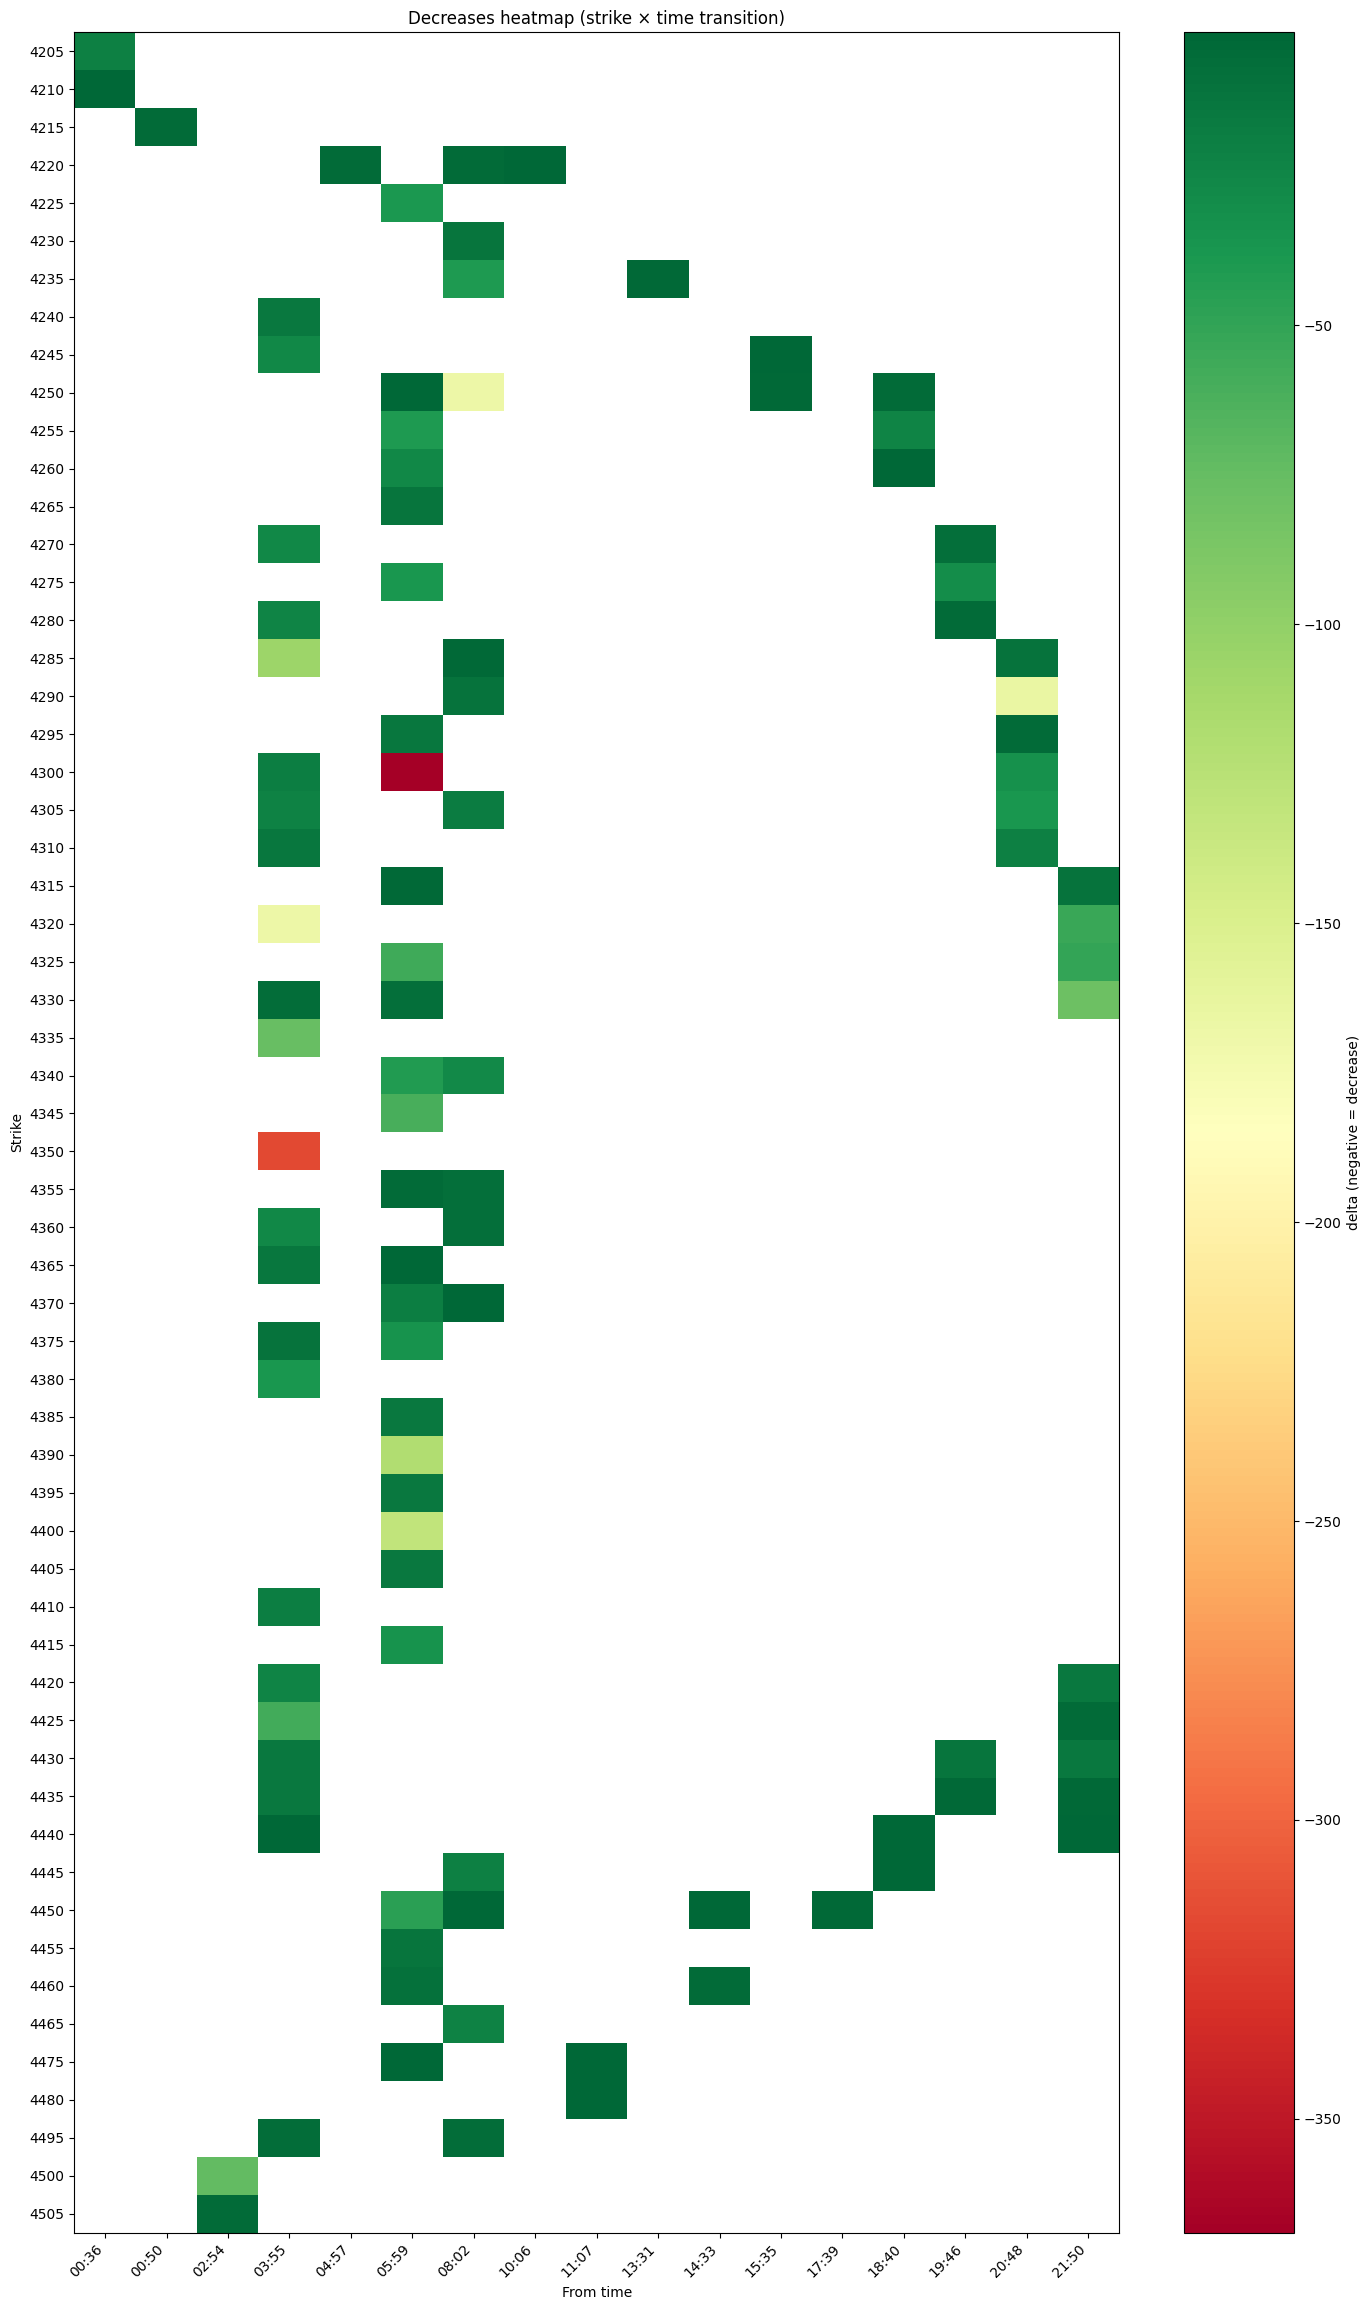

In [6]:
# ── ถ้ามี decrease: แสดง heatmap ของ transition ที่เกิดขึ้น ───────────────────
if len(dec_df) > 0:
    pivot = dec_df.pivot_table(index='strike', columns='from', values='delta', aggfunc='sum')
    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot)*0.4)))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index.astype(int))
    ax.set_title('Decreases heatmap (strike × time transition)')
    ax.set_xlabel('From time'); ax.set_ylabel('Strike')
    plt.colorbar(im, ax=ax, label='delta (negative = decrease)')
    plt.tight_layout(); plt.show()
else:
    print('ไม่มี decrease — ไม่ต้องแสดง heatmap')

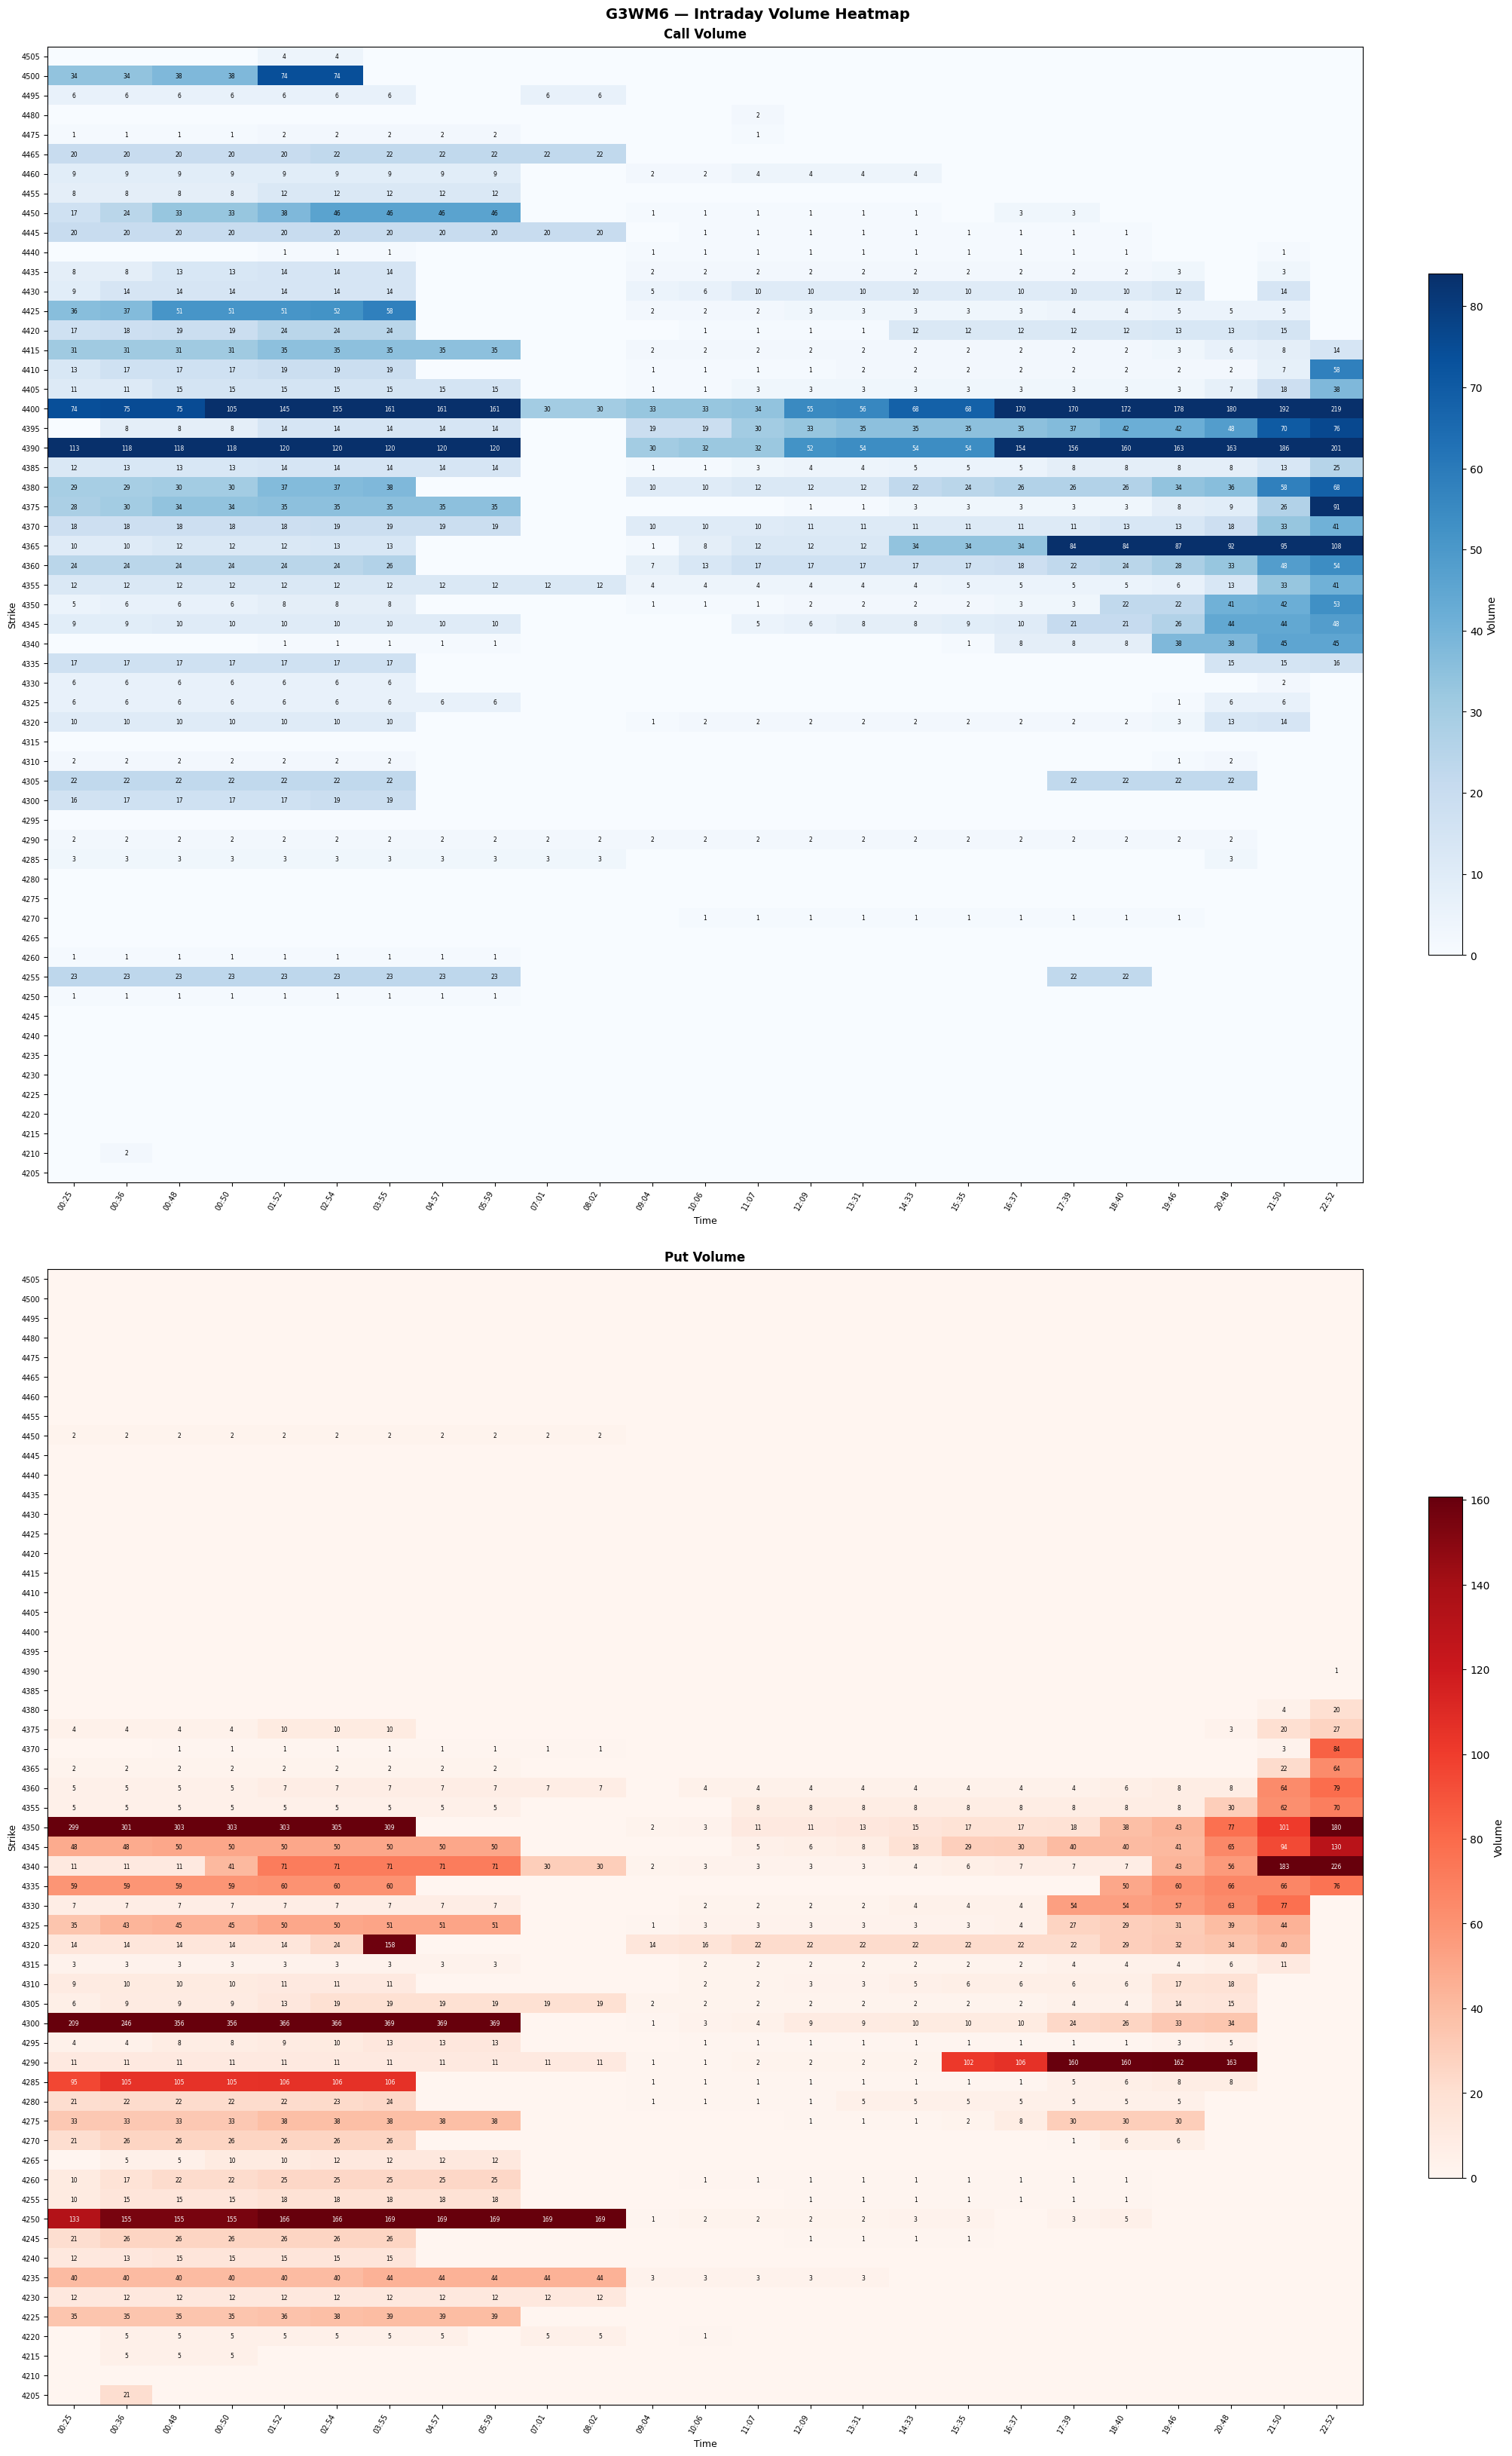

Saved: g3wm6_heatmap.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import json
from pathlib import Path

# ── โหลดข้อมูล ────────────────────────────────────────────────────────────────
SNAP_DIR = Path('../data/snapshots/vol2vol/gold/G3WM6')
files = sorted(SNAP_DIR.glob('*.json'))

rows = []
for f in files:
    d = json.loads(f.read_text())
    intra = d['tabs']['intraday']
    row = {'time': pd.to_datetime(intra['fetched_at']).strftime('%H:%M')}
    for s in intra['strikes']:
        row[f"call_{s['strike']}"] = s['call_value']
        row[f"put_{s['strike']}"]  = s['put_value']
    rows.append(row)

df = pd.DataFrame(rows)
times = df['time'].tolist()

call_cols = sorted([c for c in df.columns if c.startswith('call_')], key=lambda c: float(c.split('_')[1]))
put_cols  = sorted([c for c in df.columns if c.startswith('put_')],  key=lambda c: float(c.split('_')[1]))
strikes   = [float(c.split('_')[1]) for c in call_cols]

# กรองเฉพาะ strikes ที่มีข้อมูล (call หรือ put > 0 อย่างน้อยหนึ่ง snapshot)
mask = [(df[f'call_{s}'].max() > 0 or df[f'put_{s}'].max() > 0) for s in strikes]
strikes_f  = [s for s, m in zip(strikes, mask) if m]
call_mat   = df[[f'call_{s}' for s in strikes_f]].fillna(0).values.T   # shape (strikes, time)
put_mat    = df[[f'put_{s}'  for s in strikes_f]].fillna(0).values.T
ylabels    = [str(int(s)) for s in strikes_f[::-1]]  # descending (high strike at top)

# flip rows: high strike at top
call_mat = call_mat[::-1]
put_mat  = put_mat[::-1]

# ── วาด heatmap ───────────────────────────────────────────────────────────────
def draw_heatmap(ax, mat, title, cmap, vmax):
    im = ax.imshow(mat, aspect='auto', cmap=cmap,
                   vmin=0, vmax=vmax, interpolation='nearest')

    # ตัวเลขในแต่ละช่อง — แสดงเฉพาะ > 0
    rows_n, cols_n = mat.shape
    for r in range(rows_n):
        for c in range(cols_n):
            v = int(mat[r, c])
            if v > 0:
                # สีตัวเลข: ขาวถ้า cell มืด ดำถ้า cell สว่าง
                brightness = mat[r, c] / (vmax or 1)
                txt_color  = 'white' if brightness > 0.55 else 'black'
                ax.text(c, r, str(v), ha='center', va='center',
                        fontsize=5.5, color=txt_color, fontweight='normal')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xticks(range(len(times)))
    ax.set_xticklabels(times, rotation=60, ha='right', fontsize=7)
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=7)
    ax.set_xlabel('Time', fontsize=9)
    ax.set_ylabel('Strike', fontsize=9)
    return im

call_vmax = float(np.percentile(call_mat[call_mat > 0], 95)) if call_mat.max() > 0 else 1
put_vmax  = float(np.percentile(put_mat[put_mat > 0],  95)) if put_mat.max()  > 0 else 1

n_strikes = len(strikes_f)
fig_h     = max(14, n_strikes * 0.28)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, fig_h * 2), constrained_layout=True)
fig.suptitle('G3WM6 — Intraday Volume Heatmap', fontsize=14, fontweight='bold')

im1 = draw_heatmap(ax1, call_mat, 'Call Volume', 'Blues', call_vmax)
im2 = draw_heatmap(ax2, put_mat,  'Put Volume',  'Reds',  put_vmax)

plt.colorbar(im1, ax=ax1, shrink=0.6, label='Volume')
plt.colorbar(im2, ax=ax2, shrink=0.6, label='Volume')
plt.savefig('g3wm6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: g3wm6_heatmap.png')